In [23]:
# Importing needed code

from pathlib import Path
from typing import Callable, Literal
from datetime import datetime, time, date

import matplotlib.pyplot as plt 
import pandas as pd
import numpy as np
import statistics as stat

from data_processing.processing.figure_of_merit import fit_fom, FOM, gaussian, n_sigma_classifier, bimodal
from data_processing.reporting.plotting import plot_fom, plot_scatter

from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.stats import linregress
from scipy.signal import savgol_filter

# Load Data

In [24]:
# Defining variables for important ARC folders

alloc_code = 'st-cberling-1'
project_folder = Path('/arc/project') / alloc_code
scratch_folder = Path('scratch') / alloc_code
input_data_folder = project_folder / 'input_data'

In [25]:
# Location of PSD data folder; change as needed
PARQ_ROOT = input_data_folder / 'E-cell_Fusion_1_Jan19-2023/processed_data/unfiltered/psd'

In [26]:
%%time
# Load PSD data to "psd_report" DataFrame
psd_report = pd.read_parquet(PARQ_ROOT, columns=["CALIB_ENERGY","ENERGYSHORT", "ENERGY", "TIMETAG"])
psd_report = psd_report.astype({"CALIB_ENERGY": float, "ENERGYSHORT": int, "ENERGY": int, "TIMETAG": np.int64})

# Calculate PSD value as new column "tail / total"
psd_report["tail / total"] = (psd_report["ENERGY"] - psd_report["ENERGYSHORT"]) / psd_report["ENERGY"]
psd_report = psd_report.dropna()
psd_report = psd_report[psd_report["tail / total"].between(0,0.5)]
psd_report.head()

CPU times: user 2.46 s, sys: 408 ms, total: 2.87 s
Wall time: 2.91 s


,CALIB_ENERGY,ENERGYSHORT,ENERGY,TIMETAG,tail / total
0,0.763886,923,1088,9065858213,0.151654
1,0.255336,319,361,12179764722,0.116343
2,0.068829,77,94,23233068983,0.180851
3,0.223193,257,315,27488491909,0.184127
4,0.222495,268,314,56264741099,0.146497


In [27]:
%%time
# Generate random sample of "psd_report" for graphing
# Graphing 300M points is way too slow, so best to graph a reasonable fraction of all points

sample_frac = 0.1  # fraction of points to put in sample (0-1)
random_state = 1323  # random number generator seed; change to try different samples

if sample_frac >= 1:
    graph_sample = psd_report
else:
    graph_sample = psd_report.sample(frac=sample_frac,random_state=random_state)

CPU times: user 137 ms, sys: 891 µs, total: 138 ms
Wall time: 144 ms


In [28]:
# Define plotting variables

fontsize = 24
label_size = 22

CPU times: user 26.5 ms, sys: 0 ns, total: 26.5 ms
Wall time: 26.5 ms


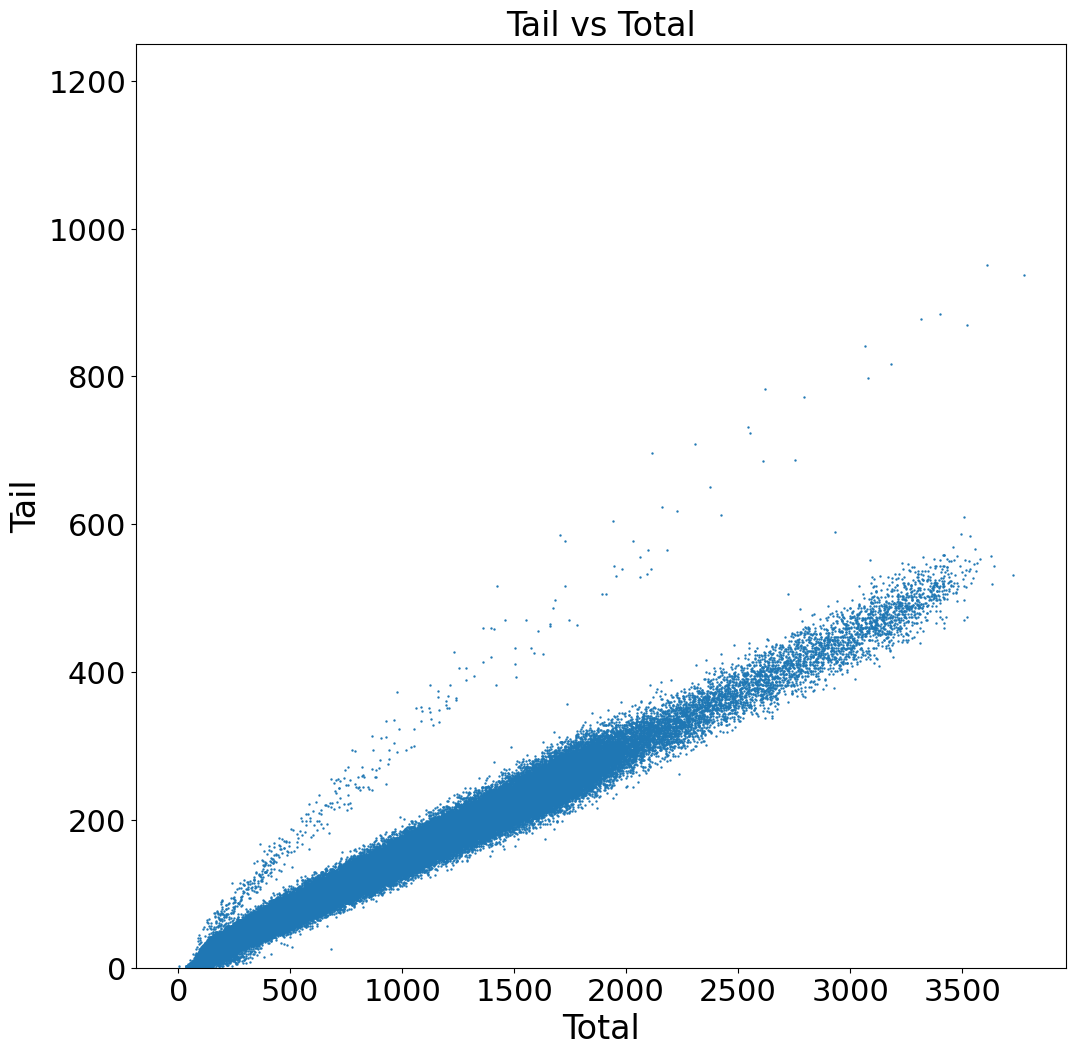

In [29]:
%%time
# Graph tail vs total scatterplot (optional, but helps diagnose data issues)
fig, ax = plt.subplots(figsize=(12,12))

ax.scatter(
    graph_sample["ENERGY"], graph_sample["ENERGY"] - graph_sample["ENERGYSHORT"], s=0.5
)

ax.set_ylim(0,1250)
ax.set_ylabel("Tail", fontsize=fontsize)
ax.set_xlabel("Total", fontsize=fontsize)
ax.set_title("Tail vs Total", fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=label_size)
ax.tick_params(axis='both', which='minor', labelsize=label_size)

CPU times: user 23.6 ms, sys: 1.94 ms, total: 25.5 ms
Wall time: 30.9 ms


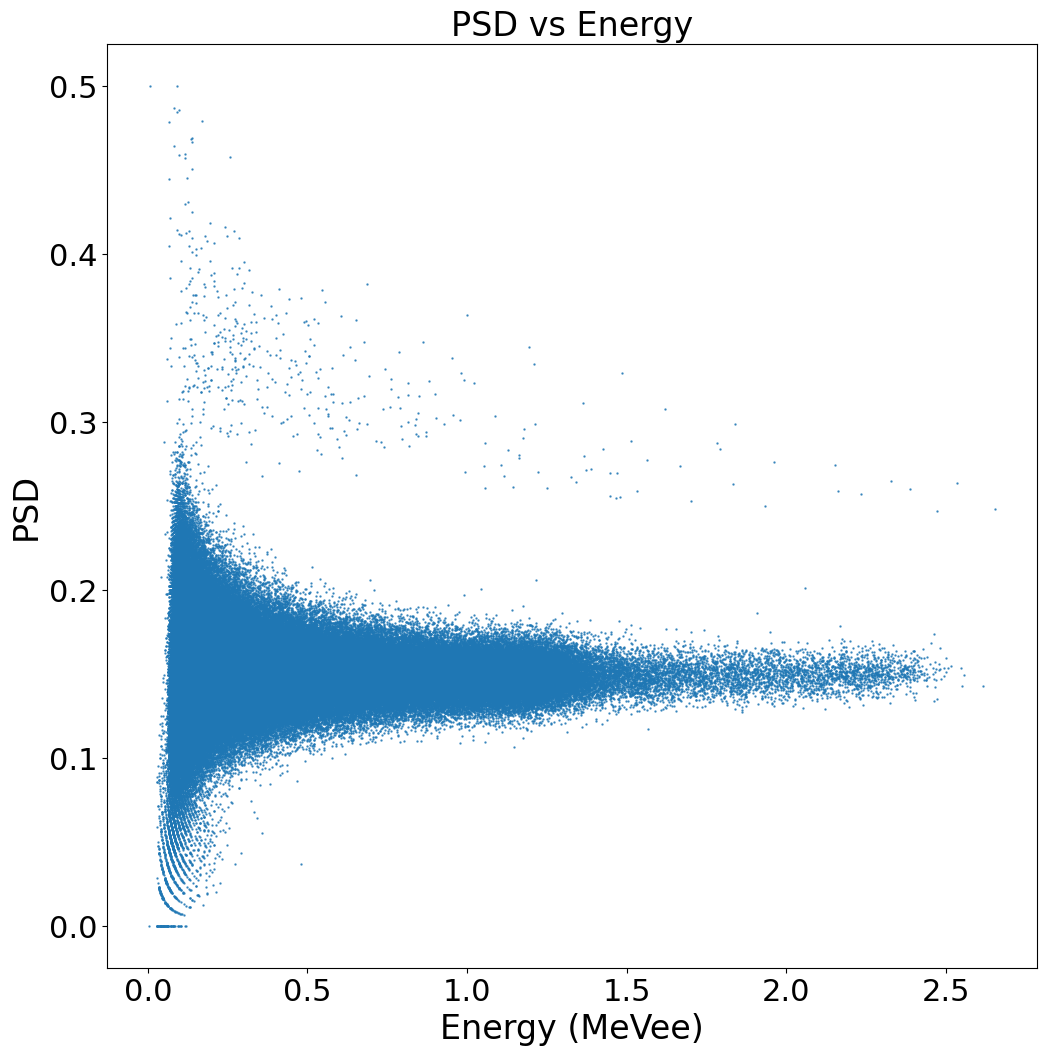

In [30]:
%%time
# Graph PSD vs Energy scatterplot
fig, ax = plt.subplots(figsize=(12,12))

ax.scatter(
    graph_sample["CALIB_ENERGY"], graph_sample["tail / total"], s=0.5, alpha=0.8
)

ax.set_ylabel("PSD", fontsize=fontsize)
ax.set_xlabel("Energy (MeVee)", fontsize=fontsize)
ax.set_title("PSD vs Energy", fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=label_size)
ax.tick_params(axis='both', which='minor', labelsize=label_size)

## Heatmap & Histograms

In [31]:
# Create 2D histogram of PSD vs Energy data
# Generates 2D grid of "bins

resolution = int(1024/2)

x, y = psd_report["CALIB_ENERGY"], psd_report["tail / total"]
Z, xe, ye = np.histogram2d(x, y, resolution)

In [32]:
# Find energy slice width
energy_slice_width = xe[2] - xe[1]
f"Energy Slice Width = {energy_slice_width:.4f} MeVee"

'Energy Slice Width = 0.0056 MeVee'

CPU times: user 68.3 ms, sys: 0 ns, total: 68.3 ms
Wall time: 71.5 ms


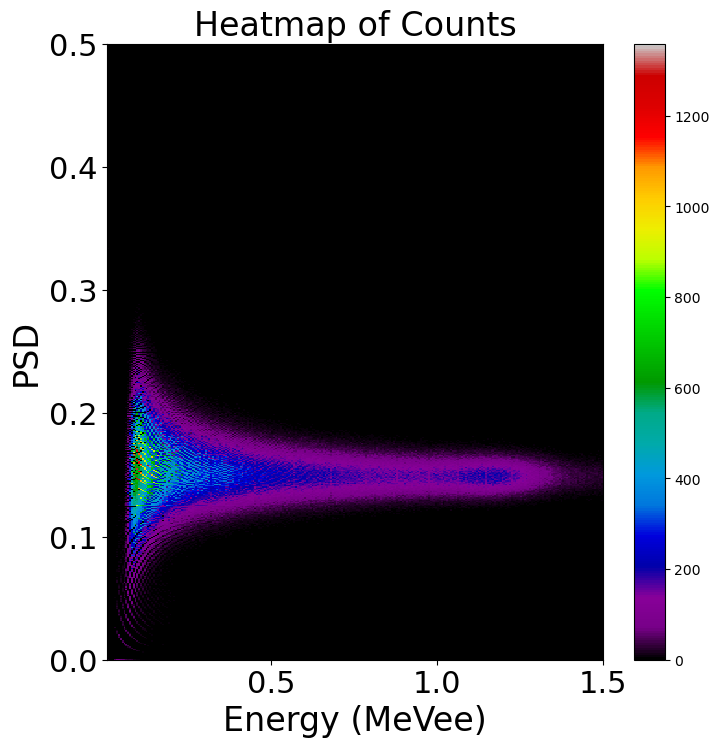

In [33]:
%%time
# Graph heatmap of 2D histogram
fig, ax = plt.subplots(figsize=(8,8))
cmap = plt.colormaps["nipy_spectral"]
pcm = ax.pcolormesh(xe, ye, Z.T, cmap=cmap)

fontsize = 24
ax.set_xlim(xe[0],1.5)
ax.set_title("Heatmap of Counts", fontsize=fontsize)
ax.set_ylabel("PSD", fontsize=fontsize)
ax.set_xlabel("Energy (MeVee)", fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=22)
ax.tick_params(axis='both', which='minor', labelsize=22)
fig.colorbar(pcm, ax=ax)

# FOM Analysis

In [34]:
# TODO delete this when we get window using Californium source
# but keep in a FOM analysis notebook for when we need to recalibrate window

In [35]:
# FOM function definition

BimodalParams = tuple[float, float, float, float, float, float]
GaussianParams = tuple[float, float, float]
BimodalBounds = tuple[BimodalParams, BimodalParams]

def split_params(
    params: BimodalParams
) -> tuple[GaussianParams, GaussianParams]:
    """Separates bimodal function parameters into 2 sets, one per component gaussian
    
    Parameters
    ----------
    params: BimodalParams
        parameters of a bimodal function
        
    Returns
    -------
    lower_gaussian_params: GaussianParams
        parameters of the lower gaussian (i.e. lower mu value)
    upper_gaussian_params: GaussianParams
        parameters of the upper gaussian (i.e. higher mu value)
    """
    params = abs(params)
    return params[0:3], params[3:]

def get_bimodal_fit(
    bins: np.ndarray, 
    histogram_slice: np.ndarray, 
    bounds: BimodalBounds
) -> tuple[GaussianParams, GaussianParams, np.ndarray]:
    """Fits a histogram slice to a bimodal distribution
    
    Parameters
    ----------
    bins: ndarray
        lower bounds of each PSD bin in the histogram
    histogram_slice: ndarray
        slice of the 2D PSD/Energy histogram taken for a specific energy (i.e. PSD vs Counts)
    bounds: BimodalBounds
        lower and upper bounds of fit parameters for this slice
        
    Returns
    -------
    gamma_params: GaussianParams
        parameters of the gaussian fit for gamma rays
    neutron_params: GaussianParams
        parameters of the gaussian fit for neutrons
    cov: ndarray
        estimated covariance of all bimodial parameters
    """
    params, cov = curve_fit(
        bimodal,
        bins,
        histogram_slice,
        bounds=bounds,
    )
    
    gamma_params, neutron_params = split_params(params)
    
    return gamma_params, neutron_params, cov


def scan_histogram_slices(
    bins: np.ndarray, 
    histogram: np.ndarray, 
    default_bounds: BimodalBounds,
    bounds: list[tuple[tuple[int, int], BimodalBounds]] | None = None, 
    start_idx: int = 0, 
    end_idx: int | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Determines bimodal fit and FOM for every energy slice in 2D PSD/Energy histogram
    
    Parameters
    ----------
    bins: ndarray
        lower bounds of each PSD bin in the histogram
    histogram: ndarray
        2D PSD/Energy histogram
    default_bounds: BimodalBounds
        default lower and upper bounds of fit parameters
    bounds: list[tuple[tuple[int, int], BimodalBounds]] | None, default None
        allows custom bounds for slice ranges. 
        Each list entry must have a tuple of start and stop indexes, and corresponding fit bounds.
        Bounds are used when the slice index falls within the start/stop range (start inclusive, stop exclusive).
        If index ranges overlap, the last matching range is used.
        If bounds is None, only default_bounds are used.
    start_idx: int, default 0
        starting index (inclusive) of slice range to fit to bimodal
    end_idx: int | None, default None
        ending index (exclusive) of slice range to fit to bimodal
        
    Returns
    -------
    fit_dataframe: DataFrame
        DataFrame of fit parameters including FOM (as columns) for each slice (as rows)
    error_dataframe: DataFrame
        DataFrame of (1 standard deviation) errors in fit parameters (as columns) for each slice (as rows)
    """
    end_idx = len(histogram) if end_idx is None else min(len(histogram), end_idx)
        
    slice_params = []
    slice_err = []
    
    for i in range(start_idx, end_idx):
        fit_bounds = default_bounds
        
        if bounds is not None :
            for i_range, bound in bounds:
                if i in range(*i_range):
                    fit_bounds = bound
        
#         print(f"default = {default_bounds}\nbounds={bounds}")
        gamma_params, neutron_params, cov = get_bimodal_fit(bins, histogram[:,i], fit_bounds)
        
        fom = FOM(*gamma_params[:-1], *neutron_params[:-1])
        
        perr = np.sqrt(np.diag(cov))
    
        slice_params.append((i, *gamma_params, *neutron_params, fom))
        slice_err.append((i, *perr))
    
    columns = ['i', 'mu1', 'sigma1', 'a1', 'mu2', 'sigma2', 'a2']
    df = pd.DataFrame(slice_params, columns=columns + ['fom'])
    err_df = pd.DataFrame(slice_err, columns=columns)
    
    return df, err_df

In [36]:
%%time
# Scan 2D histogram's energy slices and get bimodal fit

psd_bin_lbs = ye[:-1]

# Default
default_bounds = (
    (0.1, 0.01, 1, 
     0.25, 0.01, 0),
    (0.2, 0.1, Z.max(),
     0.38, 0.04, 2000)
)

bounds_a = (
    (0.1, 0.01, 1, 
     0.35, 0.01, 0),
    (0.2, 0.1, Z.max(),
     0.36, 0.04, 2000)
)

bounds_b = (
    (0.1, 0.01, 1, 
     0.34, 0.01, 0),
    (0.2, 0.1, Z.max(),
     0.36, 0.03, 2000)
)


# Ranged Example
bounds = [
    ((0,60), bounds_a),
]

start_scan_idx = 0
end_scan_idx = 420

end_scan_idx = min(end_scan_idx, len(Z))

# df_fom = find_threshold_fom_slice(psd_bin_lbs, Z.T, bounds, 0, end_scan_idx)

df, df_err = scan_histogram_slices(
    psd_bin_lbs, 
    Z.T,
    bounds=bounds,
    default_bounds=default_bounds, 
    start_idx = start_scan_idx, 
    end_idx = end_scan_idx
)


df.head()

CPU times: user 8.17 s, sys: 4.02 ms, total: 8.17 s
Wall time: 8.22 s


,i,mu1,sigma1,a1,mu2,sigma2,a2,fom
0,0,0.142626,0.01,1.0,0.350000,0.031601,1.161229e-01,2.116853
1,1,0.149889,0.01,1.0,0.354779,0.010000,4.546592e-05,4.350445
2,2,0.149889,0.01,1.0,0.354779,0.010000,4.546592e-05,4.350445
3,3,0.149880,0.01,1.0,0.354779,0.010000,4.546591e-05,4.350636
4,4,0.132315,0.01,1.0,0.354779,0.010000,4.357633e-11,4.723593


In [37]:
# Find energy slices with FOM between 1.2 and 1.3 (energy cutoff area of interest)

fom_slice_candidates = df.query("(1.2 < fom) & (fom <= 1.3)")
fom_slice_candidates

,i,mu1,sigma1,a1,mu2,sigma2,a2,fom
11,11,0.121053,0.043973,90.005907,0.360000,0.039994,0.098839,1.208464
26,26,0.154754,0.029086,514.678656,0.350000,0.040000,0.873173,1.200150
27,27,0.154402,0.028832,498.039259,0.350000,0.040000,0.807065,1.206753
28,28,0.154497,0.028199,485.952917,0.357623,0.040000,0.718990,1.264826
29,29,0.154421,0.027442,477.653959,0.350000,0.040000,0.716157,1.231503
30,30,0.154533,0.027108,402.984681,0.350000,0.040000,0.673929,1.236921
31,31,0.154015,0.026535,459.208684,0.350000,0.040000,0.651884,1.250881
32,32,0.154243,0.026154,441.692768,0.350000,0.040000,0.631968,1.256610
33,33,0.153885,0.025765,432.797160,0.350000,0.040000,0.753156,1.266360
34,34,0.153699,0.025190,424.907163,0.350050,0.040000,0.599254,1.279074


In [38]:
# Manually find FOM threshold slice (number is index of first slice past threshold)

fom_slice = fom_slice_candidates.loc[34,:]
slice_idx = int(fom_slice["i"])
fom = fom_slice["fom"]

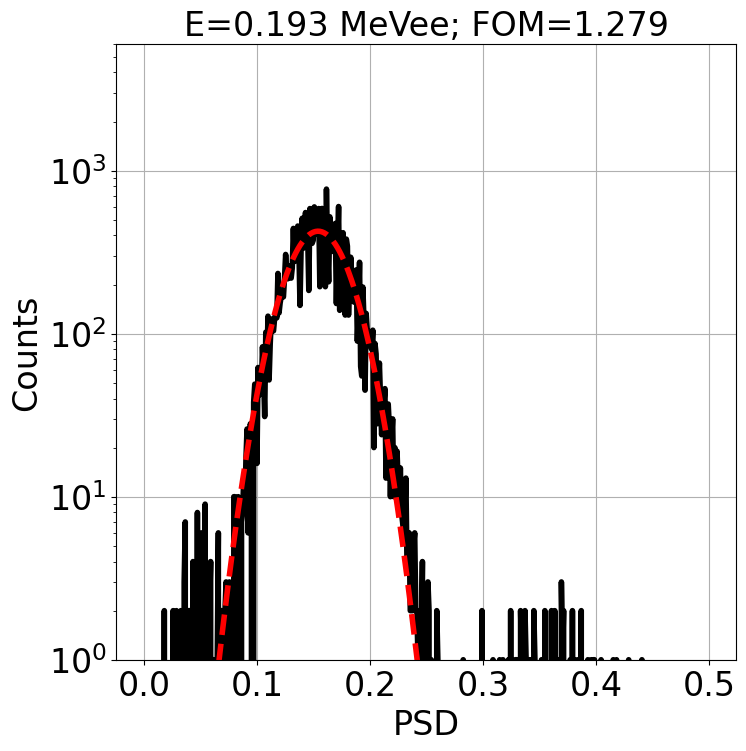

In [19]:
# Graph FOM threshold slice
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(psd_bin_lbs, Z.T[:,slice_idx], "k", lw=4)
params = tuple(df.iloc[slice_idx,1:7])
ax.plot(psd_bin_lbs, bimodal(psd_bin_lbs, *params), "r--", lw=4)
ax.set_ylim(1, 6e3)
ax.grid()
ax.set_yscale("log")
ax.set_ylabel("Counts", fontsize=fontsize)
ax.set_xlabel("PSD", fontsize=fontsize)
ax.set_title(f"E={xe[slice_idx]:.3f} MeVee; FOM={fom:.3f}", fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=fontsize)
ax.tick_params(axis='both', which='minor', labelsize=fontsize)

<IPython.core.display.Javascript object>


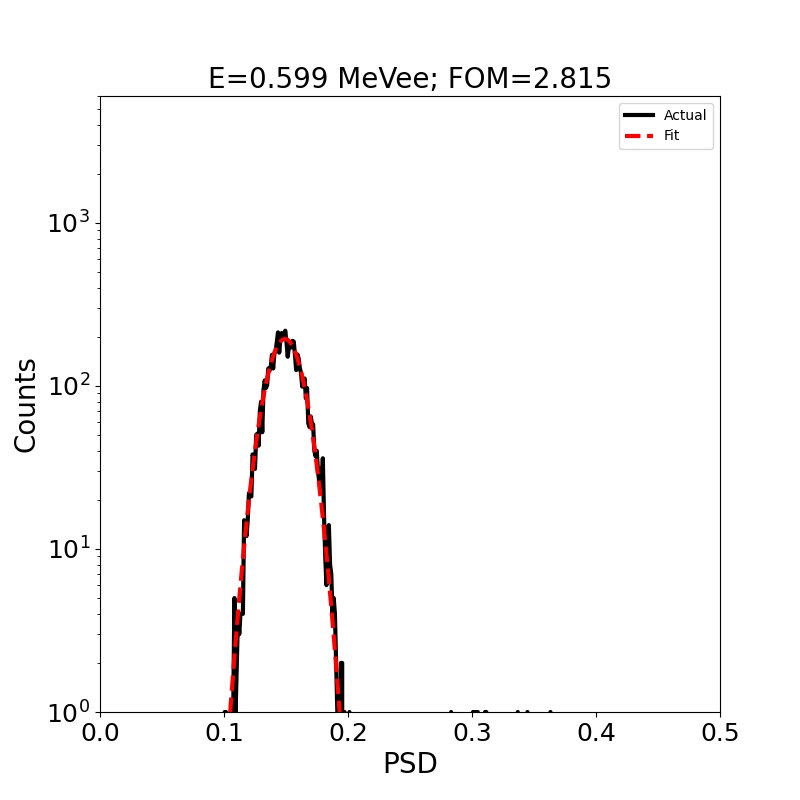

In [20]:
# Show histogram scan animation (optional, but useful for checking goodness of fit)
%matplotlib notebook
from matplotlib.animation import FuncAnimation

ylim = (1, 6e3)  # Y axis limits used (change to match data set used)
anim_fs = 20  # Font size used (axis labels and title)
anim_ls = 18  # Line size used for axis ticks
anim_lw = 3  # Line width used for line plotting
frames = range(0,120)  # slices to view
interval = 60  # delay between frames in milliseconds (lower = faster)

fig = plt.figure(figsize=(8,8))
ax = plt.axes(xlim=(0, 0.5), ylim=ylim, yscale="log")
line1, = ax.plot([], [], 'k', lw=anim_lw, label='Actual')
line2, = ax.plot([], [], 'r--', lw=anim_lw, label='Fit')

def init():
    line1.set_data([], [])
    line2.set_data([], [])
    ax.legend()
    ax.set_xlabel('PSD', fontsize=anim_fs)
    ax.set_ylabel('Counts', fontsize=anim_fs)
    ax.tick_params(axis='both', which='major', labelsize=anim_ls)
    ax.tick_params(axis='both', which='minor', labelsize=anim_ls)
    return line1, line2

def animate(i):
    x = psd_bin_lbs
    y = Z.T[:,i]
    line1.set_data(x, y)
    params = tuple(df.iloc[i,1:7])
    fom = df['fom'][i]
    y = bimodal(x, *params)
    line2.set_data(x, y)
    ax.set_title(f"E={xe[i]:.3f} MeVee; FOM={fom:.3f}", fontsize=anim_fs)

    return line1, line2

anim = FuncAnimation(fig, animate, init_func=init, frames=frames, interval=interval, blit=True)

# anim.save('../notebooks/images/FOM_graph.gif', writer='pillow')

In [21]:
# Stops interactive graph views. Allows later static graphs, but stops animation
%matplotlib inline

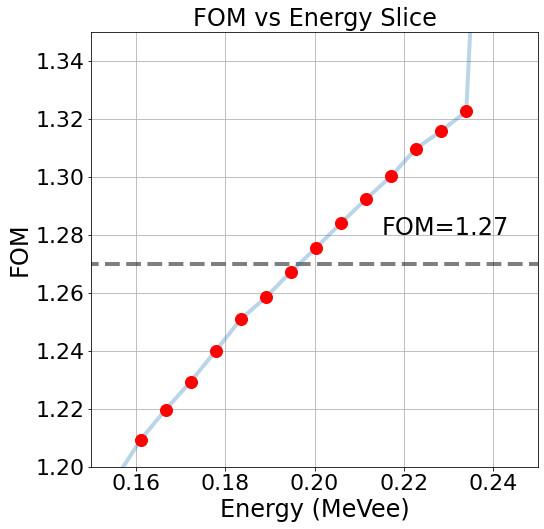

In [21]:
ylim = 1.2, 1.35  # Plot view limits on Y axis
xlim = 0.15, 0.25  # Plot view limits on X axis

fig, ax = plt.subplots(figsize=(8,8))


ax.hlines(1.27, 0, 1.25, color='k', linestyle='--', alpha=0.5, lw=4)

ax.plot(
    xe[start_scan_idx:end_scan_idx], 
    df['fom'][start_scan_idx:end_scan_idx], 
    "-",
    alpha=0.3,
    lw=4
)

ax.plot(
    xe[start_scan_idx:end_scan_idx], 
    df['fom'][start_scan_idx:end_scan_idx], 
    "ro",
    markersize=12,
)

ax.text(*(0.215, 1.27 + 0.01), "FOM=1.27", fontsize=fontsize)

ax.set_ylim(*ylim)
ax.set_xlim(*xlim)
ax.set_title("FOM vs Energy Slice", fontsize=fontsize)
ax.set_ylabel("FOM", fontsize=fontsize)
ax.set_xlabel("Energy (MeVee)", fontsize=fontsize)

# ax.legend(fontsize=fontsize)
ax.grid()
# ax.set_yticks(np.arange(1,2.25,0.25))
ax.tick_params(axis='both', which='major', labelsize=22)
ax.tick_params(axis='both', which='minor', labelsize=22)

In [22]:
# Interpolate between slices near FOM threshold to find best lower energy cutoff
fom_idx = slice_idx

fom_fit = interp1d(df["fom"][fom_idx-1:fom_idx+1], xe[fom_idx-1:fom_idx+1], kind="linear")
L0 = fom_fit(1.27)
f"FOM ENERGY CUTOFF = {L0:.4f} MeVee"

'FOM ENERGY CUTOFF = 0.1966 MeVee'

In [39]:
# TODO get L0 from Californium source analysis
# for now, using value from "UBC Background 20221214-19 Update"
L0 = 0.1966

# Counting Windows

In [40]:
# Window fitting function definition

window_adj_offset = 0

def classify(
    psd_report: pd.DataFrame, 
    lb_fit_fn: Callable[[np.ndarray], np.ndarray], 
    ub_fit_fn: Callable[[np.ndarray], np.ndarray], 
    label: str, 
    le_cutoff: float = L0
) -> pd.DataFrame:
    """Classify signals as neutron or non-neutron for a given count window
    Classification creates a new column of boolean values, where True indicates a neutron classified signal.
    
    Parameters
    ----------
    psd_report: DataFrame
        DataFrame containing signal PSD data. 
        It must have the "tail / total" (for PSD value) and "CALIB_ENERGY" (for calibrated energy) columns.
    lb_fit_fn: Callable[[ndarray], ndarray]
        A function describing the window's lower bounds
    ub_fit_fn: Callable[[ndarray], ndarray]
        A function describing the window's upper bounds
    label: str
        column label to use for signal classification results
    le_cutoff: float, default L0 (previously determined lower energy cutoff)
        Lower energy cutoff (AKA the left boundary of the neutron window)
        
    Returns
    -------
    psd_report: DataFrame
        Original DataFrame with new column for neutron classification
    """
    psd_report[label] = psd_report["tail / total"].between(
        lb_fit_fn(psd_report["CALIB_ENERGY"].astype(float)) + 
        window_adj_offset, ub_fit_fn(psd_report["CALIB_ENERGY"].astype(float))
    ) & (psd_report["CALIB_ENERGY"] >= le_cutoff)
    
    return psd_report

def plot_classification(
    neutrons: pd.DataFrame, 
    gammas: pd.DataFrame, 
    lb_fit: Callable[[float], float],
    ub_fit: Callable[[float], float],
    max_energy: float,
    FOM_cutoff: float,
    n_neutrons: int,
    label_n: str = "Neutrons",
    label_g: str = "Non-Neutrons",
) -> tuple[plt.Figure, plt.Axes]:
    """Plot detected events, showing neutron classification window
    The classification window's upper and lower PSD bound functions, as well as the energy cutoff (left side) bound,
    are shown as dotted lines. Points are color labelled to show neutron vs. non-neutron events.
    
    Parameters
    ----------
    neutrons: pd.DataFrame
        DataFrame of neutron classified events to display
    gammas: pd.DataFrame
        DataFrame of non-neutron classified events to display (assumed to be gamma rays)
    lb_fit, ub_fit: Callabl[[float], float]
        Lower and upper PSD bound functions
    max_energy: float
        maximum energy used in this plot (which determines x-axis range)
    FOM_cutoff: float
        energy cutoff, i.e. lowest energy where FOM > 1.27
    n_neutrons: int
        Actual total number of neutrons (to be displayed in title)
        This parameter is used rather than obtained from the neutrons DataFrame
        to allow data samples to be plotted for faster plotting.
    label_n: str
        Series label for neutron classified events
    label_g: str
        Series label for non-neutron classified events (AKA gamma rays)
    
    Returns
    -------
    fig: plt.Figure
        plotting container for neutron classification plot
    ax: plt.Axes
        plot axes for neutron classification plot
    
    """
    fig, ax = plt.subplots(figsize=(10,10))
    ax.scatter(gammas["CALIB_ENERGY"], gammas["tail / total"], s=2, label=label_g)
    ax.scatter(neutrons["CALIB_ENERGY"], neutrons["tail / total"], s=2, label=label_n)

    energy_space = np.linspace(xe[0], max_energy + 0.5, 200)

    ax.plot(energy_space, lb_fit(energy_space), 'r--')
    ax.plot(energy_space, ub_fit(energy_space), 'r--')
    
    ax.vlines(all_slice_xs[0], lb_fit(all_slice_xs[0]), ub_fit(all_slice_xs[0]), 'r', ls='--')

    ax.vlines(FOM_cutoff, lb_fit(FOM_cutoff), ub_fit(FOM_cutoff), 'r', ls="--")

    ax.set_title(f"Counts = {n_neutrons}", fontsize=fontsize)
    ax.set_ylim(0, 0.55)
    ax.set_xlim(0, max_energy + .05)
    
    ax.tick_params(axis='both', which='major', labelsize=22)
    ax.tick_params(axis='both', which='minor', labelsize=22)
    
    ax.set_xlabel("Energy (MeVee)", fontsize=fontsize)
    ax.set_ylabel("PSD", fontsize=fontsize)
    ax.legend(fontsize=fontsize)
    return fig, ax

In [41]:
# Define variable for all slice indexes to use
# (can be overridden if you only want to plot a subset of x axis)

all_slice_xs = xe[:end_scan_idx]

## NASA  


This classification window is based on the technique outlined in _Fast Neutron Spectroscopy With Organic Scintillation Detectors in a High-Radiation Environment_, Baramsai _et al_.

We define the lower PSD bound as N standard deviations above the gamma mean. We find these points for each slice, then use smoothing and interpolation to generate a lower bound function.

The upper bound for the window is generated by adding a fixed offset to the lower bound value (found to be 0.2 based on observation of the paper's graphs).

As in all windows, the FOM cutoff is used as the left-most bound.

In [42]:
# Define lower and upper bounds (neutron_lb_fit, neutron_ub_fit)

window_offset = 0.2
sigma = 5

neutron_lb = savgol_filter(df["mu1"] + sigma * df["sigma1"], window_length=21, polyorder=3)  # reduce noise
neutron_lb_fit = interp1d(
    all_slice_xs, 
    neutron_lb, 
    fill_value=(neutron_lb[0], neutron_lb[-1]), 
    bounds_error=False)  # now it's a function!

def neutron_ub_fit(x):
    # upper bound is just a fixed PSD offset from lower bound
    # as observed in NASA paper graphs
    return neutron_lb_fit(x) + window_offset

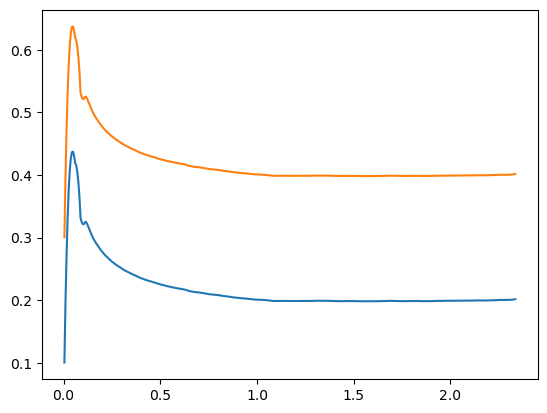

In [43]:
# Plot upper and lower bounds (diagnostic)

plt.plot(all_slice_xs, neutron_lb_fit(all_slice_xs))
plt.plot(all_slice_xs, neutron_ub_fit(all_slice_xs))

In [44]:
%%time
# Classify neutrons under NASA window
psd_report = classify(psd_report, neutron_lb_fit, neutron_ub_fit, "NASA",le_cutoff=L0)

CPU times: user 387 ms, sys: 7.88 ms, total: 395 ms
Wall time: 402 ms


In [45]:
%%time
# Recreate graph sample with classification data
del graph_sample
graph_sample = psd_report.sample(frac=sample_frac,random_state=random_state)

CPU times: user 143 ms, sys: 1.07 ms, total: 144 ms
Wall time: 149 ms


CPU times: user 46 ms, sys: 24 µs, total: 46 ms
Wall time: 46.1 ms


(<Figure size 1000x1000 with 1 Axes>,
 <AxesSubplot: title={'center': 'Counts = 3205'}, xlabel='Energy (MeVee)', ylabel='PSD'>)

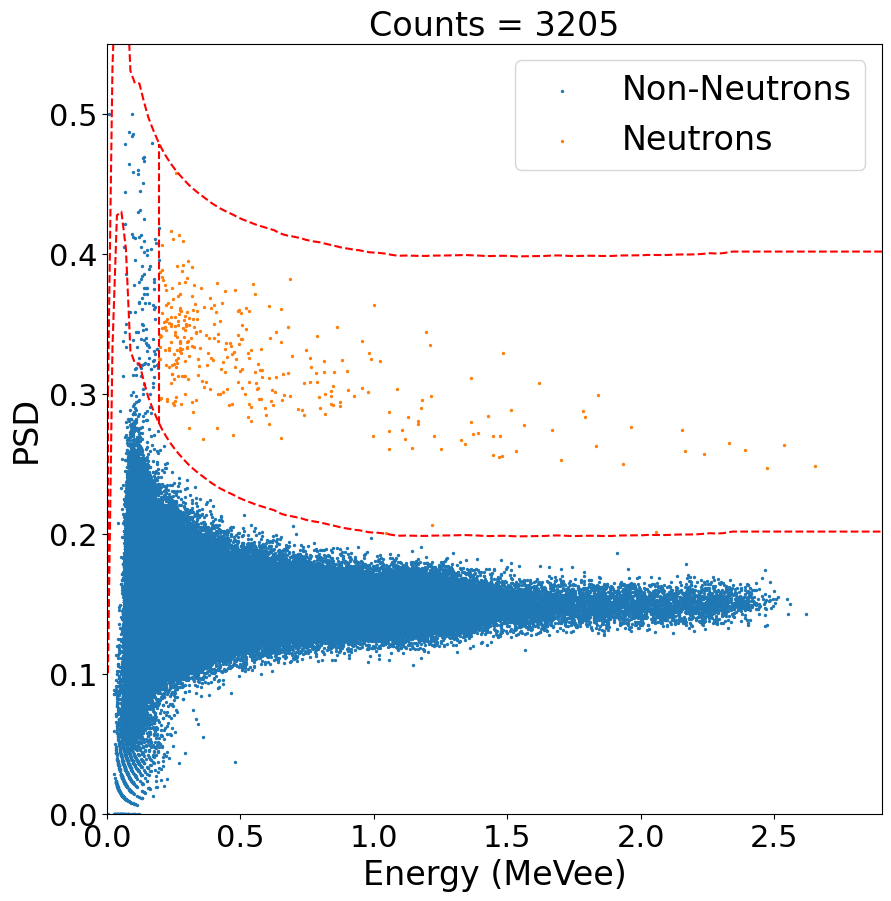

In [46]:
%%time
# Plotting NASA classification
plot_classification(
    graph_sample[graph_sample["NASA"]], 
    graph_sample[~graph_sample["NASA"]], 
    neutron_lb_fit, 
    neutron_ub_fit, 
    psd_report["CALIB_ENERGY"].max(), 
    L0,
    psd_report[psd_report["NASA"]].shape[0]
)


# plt.plot(all_slice_xs, df["mu2"])
# plt.plot(all_slice_xs, df["mu1"] + 4 * df["sigma1"])
# plt.xlim(0.2,0.4)
# plt.ylim(0.3, 0.5)

# CPS

In [54]:
%%time
# Defining count rate functions

def counts_over_time_histogram(
    timetags: pd.Series, 
    dwell_time: int, 
    total_time: float
) -> tuple[np.ndarray, np.ndarray]:
    """Generates histogram of event counts per dwell time bin
    Due to limitations of data acquisition, the first bin is ignored, as it gives inaccurately low values.
    
    Parameters
    ----------
    timetags: pd.Series
        timetags for all relevant events 
    dwell_time: int
        time period used for histogram bin width in seconds
    total_time: float
        total data acquisition time in seconds
        
    Returns
    -------
    counts: np.ndarray
        array of counts per bin
    bins: np.ndarray
        bin boundaries (as time in seconds)
    """
    if total_time % dwell_time == 0:
        total_time += 0.001
    input_bins = np.arange(0, total_time, dwell_time)
    counts, bins = np.histogram(timetags, input_bins)
    return counts[1:], bins[1:]


def plot_histogram(
    bins: list[np.ndarray], 
    counts: list[np.ndarray],
    labels: list[str],
    style: Literal['points', 'stairs'] = "points",
    **kwargs
) -> tuple[plt.Figure, plt.Axes]:
    """Plot a set of histograms in one figure
    
    Parameters
    ----------
    bins: list[np.ndarray]
        list of histogram bins to use
    counts: list[np.ndarray]
        list of histogram counts to use
        Each list element must correspond to the element in the same position in `bins`
    labels: list[str]
        list of labels to use
        Each list element must correspond to the element in the same position in `bins`
    style: Literal['points', 'stairs'], default "points"
        plotting style
        The 'points' option creates a scatterplot, while 'stairs' creates a stair plot.
    kwargs
        Other formatting options used in the Matplotlib Axes.plot() or Axes.stairs() functions (as appropriate)
    
    Returns
    -------
    fig: plt.Figure
        plotting container for histogram plot
    ax: plt.Axes
        plot axes for histogram plot
    
    """
    fig, ax = plt.subplots(dpi=140)
    
    for bin, count, label in zip(bins, counts, labels):
        if style == "points":
            ax.plot(bin[:-1], count, "o", label=label, **kwargs)
        
        elif style == "stairs":
            ax.stairs(count, bin, label=label, lw=4, **kwargs)
    
    ax.legend()
    return fig, ax

CPU times: user 40 µs, sys: 4 µs, total: 44 µs
Wall time: 48.2 µs


In [56]:
psd_report['TIMETAG_HOURS'] = psd_report['TIMETAG'] * 1e-12/3600
print(psd_report[['TIMETAG', 'TIMETAG_HOURS']].head())
print(psd_report[['TIMETAG', 'TIMETAG_HOURS']].tail())

       TIMETAG  TIMETAG_HOURS
0   9065858213       0.000003
1  12179764722       0.000003
2  23233068983       0.000006
3  27488491909       0.000008
4  56264741099       0.000016
                   TIMETAG  TIMETAG_HOURS
2629600  22141646370453053       6.150457
2629601  22141667941950354       6.150463
2629602  22141673031134860       6.150465
2629603  22141688476758276       6.150469
2629604  22141697493284003       6.150472


In [48]:
# Display total time
total_time = psd_report["TIMETAG"].max() * 1e-12 # s
f"Total time = {total_time:.3f}s"

'Total time = 22141.697s'

## Plasma Period Classification

In [64]:
def timestamp_generator(start_time: time) -> Callable[[time], int]:
    """Get a function that generates timestamps from the start time
    
    Parameters
    ----------
    
    """
    # TODO finish docstring
    def get_timestamp(end_time: time) -> int:
        end_datetime = datetime.combine(date.today(), end_time)
        start_datetime = datetime.combine(date.today(), start_time)
        total_seconds = end_datetime - start_datetime
        return int(total_seconds.total_seconds() * 1e12)
    
    return get_timestamp

# start_time = time.fromisoformat('00:00:00')
# end_time = time.fromisoformat('00:00:13')
# get_timestamp = timestamp_generator(start_time)
# timestamp = get_timestamp(end_time)
# timestamp

def offsets_from_timestrings(timestrings: list[str]) -> list[timedelta]:
    def offset_from_timestring(timestring: str) -> timedelta:
    hour_str, min_str, sec_str = timestring.split(":")
    return timedelta(
        hours=int(hour_str),
        minutes=int(min_str),
        seconds=int(sec_str)
    )
    
    return [offset_from_timestring(timestring) for timestring in timestrings]

def classify_period(
    dataframe: pd.DataFrame,
    column_name: str, 
    detector_start: time, 
    gas_analyzer_start: time, 
    start_offsets: list[timedelta] | None = None,
    end_offsets: list[timedelta] | None = None,
    period_duration: timedelta | None = None
) -> something:
    """TODO docstring
    """
    # Adds column to dataframe classifying events 
    # as happening in any of a series of time intervals
    # Start and end times are delta from gas_analyzer_start
    
    if period_duration is not None:
        if start_offsets is None and end_offsets is None:
            raise ValueError(
                "At least 2 of start_times, end_times and period_duration must be given."
            )
    else:
        if start_offsets is None or end_offsets is None:
            raise ValueError(
                "At least 2 of start_times, end_times and period_duration must be given."
            )
    
    if start_offsets is not None and end_offsets is not None and len(start_offsets) != len(end_offsets):
        raise ValueError(
            "Start and end offsets must have the same length"
        )
    
    if start_offsets is not None:
        start_times = [gas_analyzer_start + delta for delta in start_offsets]
    if end_offsets is not None:
        end_times = [gas_analyzer_start + delta for delta in start_offsets]
        
    if start_offsets is None:
        start_times = [end_time - period_duration for end_time in end_times]
    if end_offsets is None:
        end_times = [start_time + period_duration for start_time in start_times]
        
    get_timestamp = timestamp_generator(gas_analyzer_start)
    # TODO create timestamps
    # TODO zip starts and ends
    # TODO create bool series for each interval using between
    # TODO use df.any() to create classification series
    # TODO add classification series to dataframe and return

In [65]:
get_timestamp = timestamp_generator(time.fromisoformat('11:54:00'))

In [72]:
# TODO define start time and use time deltas
# TODO calculate one side using other side and period duration

on_start_times = [time.fromisoformat(time_str) for time_str in ['12:41:00', '15:42:00']]
on_end_times = [time.fromisoformat(time_str) for time_str in ['13:26:00', '16:27:00']]
on_start_timestamps = [*map(get_timestamp, on_start_times)]
on_end_timestamps = [*map(get_timestamp, on_end_times)]

off_start_times = [time.fromisoformat(time_str) for time_str in ['14:13:00', '16:28:00']]
off_end_times = [time.fromisoformat(time_str) for time_str in ['14:58:00', '17:13:00']]
off_start_timestamps = [*map(get_timestamp, off_start_times)]
off_end_timestamps = [*map(get_timestamp, off_end_times)]

on_periods = zip(on_start_timestamps, on_end_timestamps)
off_periods = zip(off_start_timestamps, off_end_timestamps)

In [73]:
on_start_timestamps

[2820000000000000, 13680000000000000]

In [74]:
device_name = "ECELL"

# TODO figure out how to do this with loops
# for period in on_periods:
#     start, end = period
#     psd_report[f"{device_name}_ON"] = psd_report["TIMETAG"].between(start, end)

# for period in off_periods:
#     start, end = period
#     psd_report[f"{device_name}_OFF"] = psd_report["TIMETAG"].between(start, end)

on_periods = list(on_periods)
off_periods = list(off_periods)

psd_report[f"{device_name}_ON"] = psd_report["TIMETAG"].between(
    on_start_timestamps[0], on_end_timestamps[0]
) | psd_report["TIMETAG"].between(
    on_start_timestamps[1], on_end_timestamps[1]
) 

psd_report[f"{device_name}_OFF"] = psd_report["TIMETAG"].between(
    off_start_timestamps[0], off_end_timestamps[0]
) | psd_report["TIMETAG"].between(
    off_start_timestamps[1], off_end_timestamps[1]
)

,CALIB_ENERGY,ENERGYSHORT,ENERGY,TIMETAG,tail / total,NASA,ECELL_ON,ECELL_OFF,TIMETAG_HOURS
0,0.763886,923,1088,9065858213,0.151654,False,False,False,0.000003
1,0.255336,319,361,12179764722,0.116343,False,False,False,0.000003
2,0.068829,77,94,23233068983,0.180851,False,False,False,0.000006
3,0.223193,257,315,27488491909,0.184127,False,False,False,0.000008
4,0.222495,268,314,56264741099,0.146497,False,False,False,0.000016


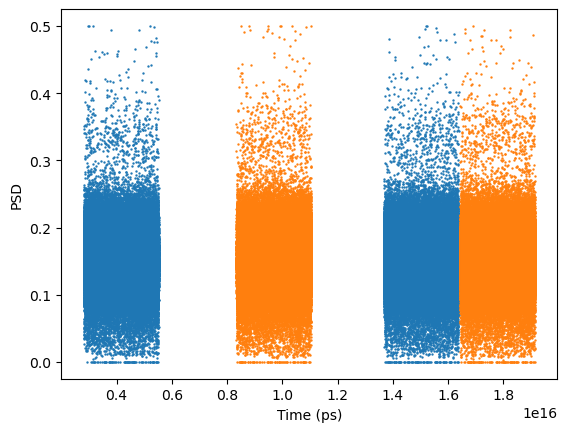

In [76]:
test = psd_report[psd_report["ECELL_ON"]]
test2 = psd_report[psd_report["ECELL_OFF"]]
plt.scatter(test["TIMETAG"], test["tail / total"], s=0.5)
plt.scatter(test2["TIMETAG"], test2["tail / total"], s=0.5)
plt.ylabel("PSD")
plt.xlabel("Time (ps)")
psd_report.head()
# print(test2.shape)

## NASA Classification Window

In [35]:
# Define dwell time
dwell_time = 60*5 # s

In [37]:
%time
# Generate counts per dwell time

neutron_time_counts, neutron_time_bins = counts_over_time_histogram(
    psd_report[psd_report["NASA"]]["TIMETAG"] * 1e-12, dwell_time, total_time
)

gamma_time_counts, gamma_time_bins = counts_over_time_histogram(
    psd_report[~psd_report["NASA"]]["TIMETAG"]  * 1e-12, dwell_time, total_time
)

CPU times: user 3 µs, sys: 0 ns, total: 3 µs
Wall time: 6.68 µs


In [38]:
# Generate count rates for each dwell time bin
neutron_time_cps = neutron_time_counts / dwell_time
gamma_time_cps = gamma_time_counts / dwell_time

In [40]:
# Determine count rate mean and standard deviation (2 methods)

total_count = psd_report.query("NASA == True").shape[0]
neutron_mean = np.average(neutron_time_cps)
neutron_count_sigma = np.sqrt(total_count)/total_time
neutron_cps_sigma = stat.stdev(neutron_time_cps)
print(f"Mean Count Rate: {neutron_mean:.4f} 1/s\nSigma (over all dwell rates): {neutron_cps_sigma:.4f} 1/s")
print(f"Count Rate Standard Deviation (using total count): {neutron_count_sigma:.4f} 1/s")

Mean Count Rate: 0.1450 1/s
Sigma (over all dwell rates): 0.0250 1/s
Count Rate Standard Deviation (using total count): 0.0026 1/s


CPU times: user 15.2 ms, sys: 0 ns, total: 15.2 ms
Wall time: 15.2 ms


Text(0.5, 0, 'Time (hrs)')

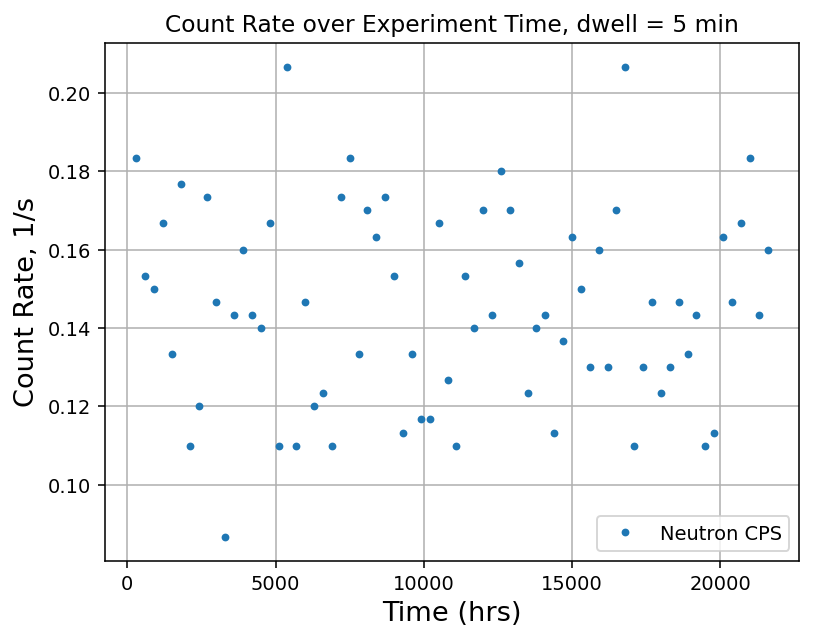

In [41]:
%%time
# Plot neutron count rate over experiment run time
fig, ax = plot_histogram(
    [neutron_time_bins],#, gamma_time_bins],
    [neutron_time_cps],#, gamma_time_cps],
    labels=["Neutron CPS", "Non-Neutron CPS"],
    markersize =3,
)



#ax.set_yscale('log')
ax.grid()
ax.set_title("Count Rate over Experiment Time, dwell = 5 min")
ax.set_ylabel("Count Rate, 1/s", fontsize=14)
ax.set_xlabel("Time (hrs)", fontsize=14)
#ax.set_xlim(0.075, 0.25)

Text(0.5, 0, 'Time (hrs)')

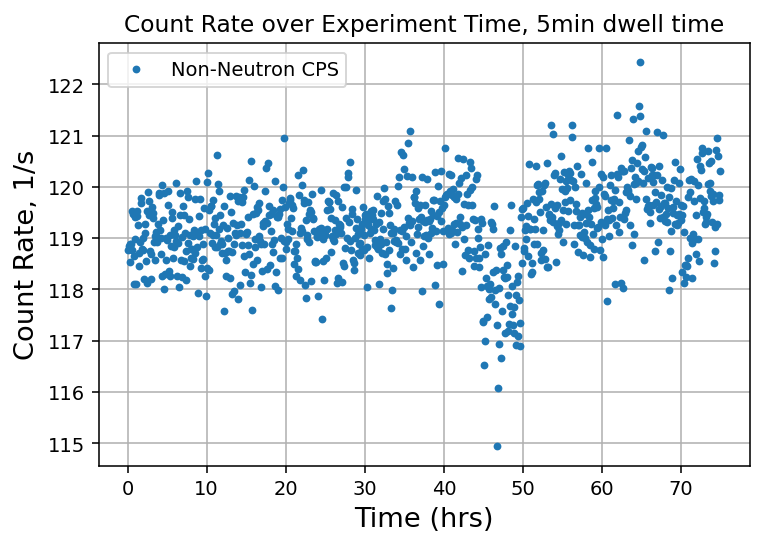

In [85]:
# Plot non-neutron (gamma ray) count rate over experiment run time
fig, ax = plot_histogram(
    [gamma_time_bins],
    [gamma_time_cps],
    labels=["Non-Neutron CPS"],
    markersize=3,
)

#ax.set_yscale('log')
ax.grid()
ax.set_title("Count Rate over Experiment Time, 5min dwell time")
ax.set_ylabel("Count Rate, 1/s", fontsize=14)
ax.set_xlabel("Time (hrs)", fontsize=14)
#ax.set_xlim(0.075, 0.25)

In [86]:
# Create count rate histogram for neutrons and gamma rays
cps_n_bins = 450

neutron_cps_counts, neutron_cps_bins = np.histogram(neutron_time_cps, cps_n_bins)
gamma_cps_counts, gamma_cps_bins = np.histogram(gamma_time_cps, cps_n_bins)


f"CPS Bin Width: {gamma_cps_bins[2] - gamma_cps_bins[1]:.4f} 1/s"

'CPS Bin Width: 0.0167 1/s'

In [87]:
# TODO determine if this is needed (since similar code exists above)
# neutron_mean = np.average(neutron_time_cps)
# neutron_sigma = np.sqrt(neutron_mean / len(neutron_time_cps))
# print(f"Mean: {neutron_mean}\nSigma: {neutron_sigma}")
# print(neutron_time_counts)

(0.075, 0.25)

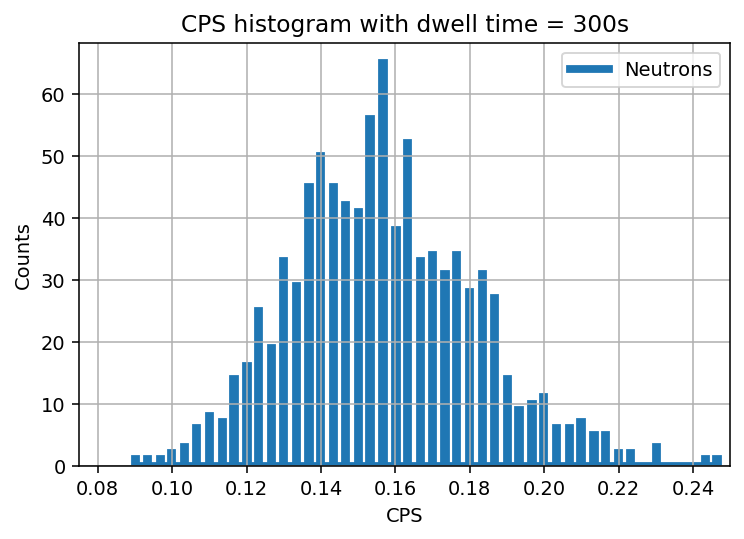

In [88]:
# Plot count rate histogram for neutrons
fig, ax = plot_histogram(
    [neutron_cps_bins, gamma_cps_bins],
    [neutron_cps_counts, gamma_cps_counts],
    style="stairs",
    labels=["Neutrons"]
)


ax.grid()
ax.set_xlabel("CPS")
ax.set_ylabel("Counts")
ax.set_title(f"CPS histogram with dwell time = {dwell_time}s")
ax.set_xlim(0.075, 0.25)

## Straight Edge

In [89]:
# Define dwell time
dwell_time = 1 #s

In [90]:
# Generate counts per dwell time
neutron_time_counts, neutron_time_bins = counts_over_time_histogram(
    psd_report[psd_report["straight"]]["TIMETAG"] * 1e-12, dwell_time, total_time
)

gamma_time_counts, gamma_time_bins = counts_over_time_histogram(
    psd_report[~psd_report["straight"]]["TIMETAG"]  * 1e-12, dwell_time, total_time
)

In [91]:
# Plot counts per dwell over time (not needed)
# fig, ax = plot_histogram(
#     [neutron_time_bins, gamma_time_bins],
#     [neutron_time_counts, gamma_time_counts],
#     labels=["Neutron Counts", "Gamma Counts"]
# )

# ax.set_title("Event Counts per Dwell Time over Experiment Time")
# ax.set_ylabel("Event Counts", fontsize=14)
# ax.set_xlabel("Time (s)", fontsize=14)

In [92]:
# Generate count rates for each dwell time bin
neutron_time_cps = neutron_time_counts / dwell_time
gamma_time_cps = gamma_time_counts / dwell_time

Text(0.5, 0, 'Time (s)')

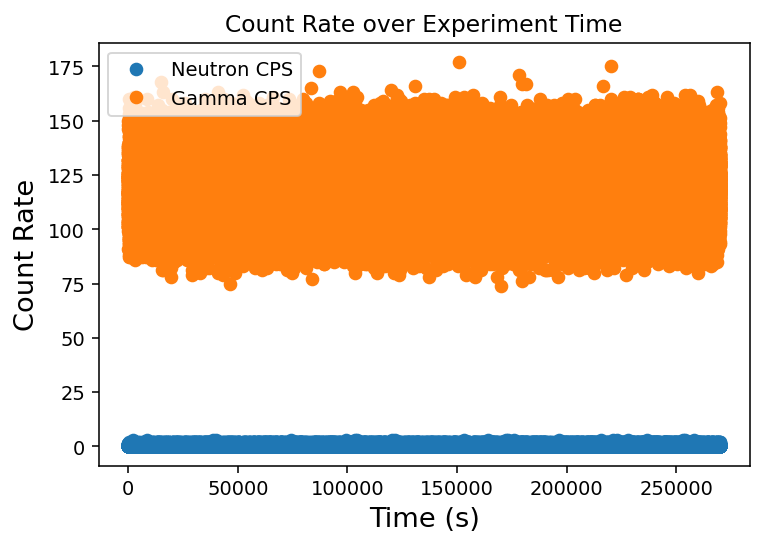

In [93]:
# Plot count rates over experiment run time
fig, ax = plot_histogram(
    [neutron_time_bins, gamma_time_bins],
    [neutron_time_cps, gamma_time_cps],
    labels=["Neutron CPS", "Gamma CPS"]
)

ax.set_title("Count Rate over Experiment Time")
ax.set_ylabel("Count Rate", fontsize=14)
ax.set_xlabel("Time (s)", fontsize=14)

In [94]:
# Create count rate histogram for neutrons and gamma rays
cps_n_bins = 124

neutron_cps_counts, neutron_cps_bins = np.histogram(neutron_time_cps, cps_n_bins)
gamma_cps_counts, gamma_cps_bins = np.histogram(gamma_time_cps, cps_n_bins)


f"CPS Bin Width: {gamma_cps_bins[2] - gamma_cps_bins[1]:.4f}s"

'CPS Bin Width: 0.8306s'

Text(0.5, 1.0, 'CPS histogram with dwell Time = 1s')

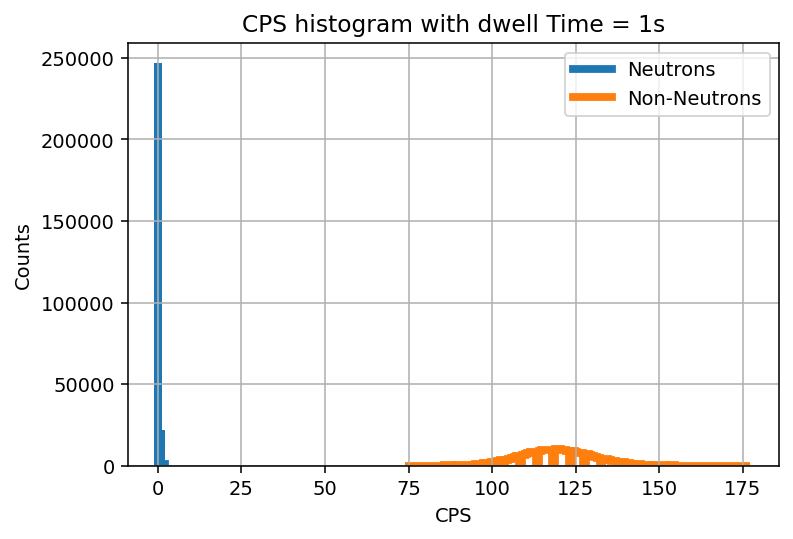

In [95]:
# Plot count rate histogram for neutrons and non-neutrons
fig, ax = plot_histogram(
    [neutron_cps_bins, gamma_cps_bins],
    [neutron_cps_counts, gamma_cps_counts],
    style="stairs",
    labels=["Neutrons", "Non-Neutrons"]
)


ax.grid()
# ax.set_ylim(0, 40)
# ax.set_xlim(100, 300)
ax.set_xlabel("CPS")
ax.set_ylabel("Counts")
ax.set_title(f"CPS histogram with dwell Time = {dwell_time}s")

# Covers

In [96]:
# Define dwell time
dwell_time = 1 #s

In [97]:
# Generate counts per dwell time
neutron_time_counts, neutron_time_bins = counts_over_time_histogram(
    psd_report[psd_report["neutron_cover"]]["TIMETAG"] * 1e-12, dwell_time, total_time
)

gamma_time_counts, gamma_time_bins = counts_over_time_histogram(
    psd_report[~psd_report["gamma_cover"]]["TIMETAG"]  * 1e-12, dwell_time, total_time
)

In [98]:
# Plot counts per dwell over time (not needed)
# fig, ax = plot_histogram(
#     [neutron_time_bins, gamma_time_bins],
#     [neutron_time_counts, gamma_time_counts],
#     labels=["Neutron Counts", "Gamma Counts"]
# )

# ax.set_title("Event Counts per Dwell Time over Experiment Time")
# ax.set_ylabel("Event Counts", fontsize=14)
# ax.set_xlabel("Time (s)", fontsize=14)

In [99]:
# Generate count rates for each dwell time bin
neutron_time_cps = neutron_time_counts / dwell_time
gamma_time_cps = gamma_time_counts / dwell_time

Text(0.5, 0, 'Time (s)')

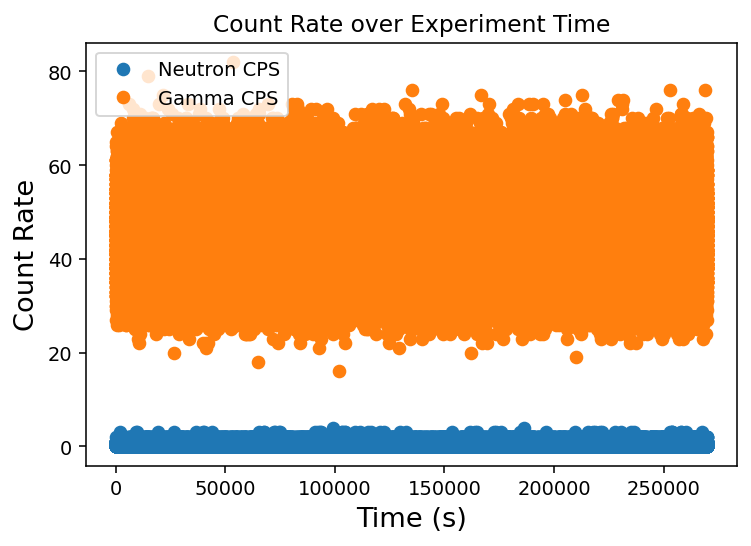

In [100]:
# Plot count rates over experiment run time
fig, ax = plot_histogram(
    [neutron_time_bins, gamma_time_bins],
    [neutron_time_cps, gamma_time_cps],
    labels=["Neutron CPS", "Gamma CPS"]
)

ax.set_title("Count Rate over Experiment Time")
ax.set_ylabel("Count Rate", fontsize=14)
ax.set_xlabel("Time (s)", fontsize=14)

In [101]:
# Create count rate histogram for neutrons and gamma rays
cps_n_bins = 124

neutron_cps_counts, neutron_cps_bins = np.histogram(neutron_time_cps, cps_n_bins)
gamma_cps_counts, gamma_cps_bins = np.histogram(gamma_time_cps, cps_n_bins)


f"CPS Bin Width: {gamma_cps_bins[2] - gamma_cps_bins[1]:.4f}s"

'CPS Bin Width: 0.5323s'

Text(0.5, 1.0, 'CPS histogram with dwell Time =1s')

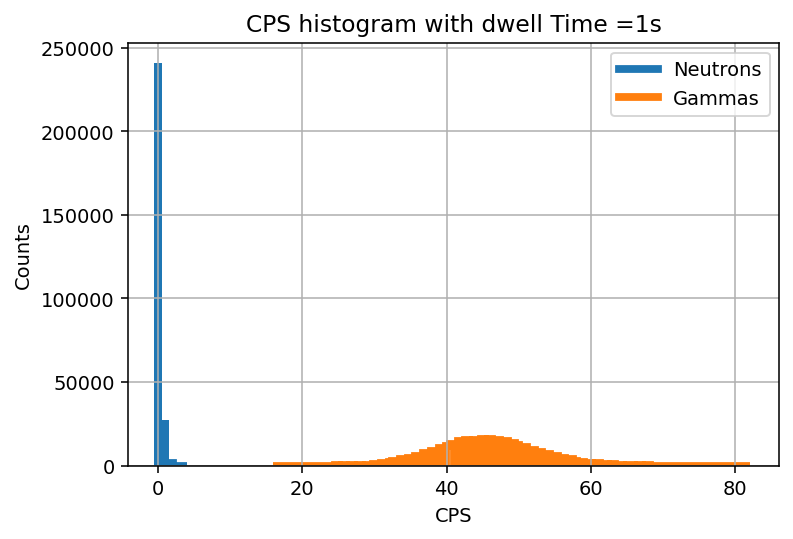

In [103]:
# Plot count rate histogram for neutrons
fig, ax = plot_histogram(
    [neutron_cps_bins, gamma_cps_bins],
    [neutron_cps_counts, gamma_cps_counts],
    style="stairs",
    labels=["Neutrons", "Gammas"]
)


ax.grid()
# ax.set_xlim(100,400)
# ax.set_ylim(0,50)
ax.set_xlabel("CPS")
ax.set_ylabel("Counts")
ax.set_title(f"CPS histogram with dwell Time ={dwell_time}s")